# Koneoppimisprojekti - [otsikko tähän]

### 1. Business Understanding

Projektin tavoitteena on tutkia Turun AMK:n opinnäytetöihin liittyvää dataa koneoppimisen metodien avulla. 

Datana käytetään vuosina 2017-2022 kerättyä metadataa, joka ei sisällä varsinaisesti opinnäytetöitä itsessään:  datassa on eritelty mm. eri lähteiden määrät (esim. painettu, internet), sivumäärä, sanamäärä, opintopisteet ja opiskeluoikeuden pituus ja työn arvosana.

Tarkoitus on tutkia metadatan muuttujien vaikutusta arvosanaan. Korrelaatioiden lisäksi kehitämme koneoppimismallin, joka pyrkii ennustamaan arvosanan (liukulukuna 1.0 ... 5.0) ja hajonnan tälle. Testaamme mallia ja vertaamme sen tulosten tarkkuutta satunnaiseen arvaamiseen tai keskiarvoon.

Oletuksemme on, että muut muuttujat vaikuttavat, joskin heikosti, arvosanaan. Liian suuret korrelaatiot tai vahvat ennusteet ovat myös huolestuttava merkki: pelkkien oheismuuttujien perusteella ei tulisi voida ennustaa arvosanaa hyvin tarkasti.

__Keskeiset tutkimuskysymykset:__

- Mitkä opinnäytetyön metadatan muuttujat vaikuttavat eniten arvosanaan?
- Kuinka tarkasti tai luotettavasti on mahdollista ennustaa opinnäytetyön arvosanaa pelkän metadatan perusteella?

### 2. Data Understanding

Keräsimme datan Avoin data -palvelusta. (https://avoindata.suomi.fi/data/fi/dataset/opinnaytetyot-tieto-ja-viestintatekniikka-metadata)

Aineiston sivulla Avoin data -palvelussa kuvataan datan keräämisestä Theseus-palvelusta, sekä sen sisältämät kentät. Lainaus:

>Suurin osa Turun ammattikorkeakoulun opinnäytetöistä on vapaasti luettavissa suomalaisten ammattikorkeakoulujen yhteisessä opinnäytetyötietokannassa, Theseuksessa. Tähän aineistoon on kerätty metadataa vuosien 2017-2022 tieto- ja viestintätekniikan suomenkielisen tutkinto-ohjelman julkaisuista.
>
>Datasetistä on jätetty pois kaikki työt, joiden metatadaa ei ole voitu lukea kokonaisuudessaan.
>
>Kenttä supervisor id vastaa English-taught ICT degree program datasetin kenttää (=osa ohjaajista on samoja molemmissa dataseteissä)
>
>Aineisto sisältää seuraavat kentät:
>
>- Total References – Kaikkien lähteiden määrä
>- Printed References - Painettujen lähteiden määrä
>- Internet Refrences - Sähköisten lähteiden määrä
>- Weak References - Heikkojen lähteiden määrä (wikipedia, reddit, blog, youtube)
>- Pages – Sivumäärä
>- Total Word Count – Sanamäärä
>- Study Credits - Opintopisteiden määrä valmistuessa
>- Study Entitlement Days - Opinto-oikeuden pituus päivinä
>- Grade - Opinnäytetyön arvosana (1-5)
>- Supervisor ID - Valvojan ID
>- Keywords – Avainsanat ja niiden esiintymismäärä
>- Total Occurences – Avainsanojen yhteenlaskettu esiintymismäärä
>
>Opinnäytetyöt tuotettu ryhmätyönä arvioidaan erikseen, ja niiden metadata voi ilmaantua useita kertoja. 

Aineisto koostuu suomen- ja englanninkielisistä opinnäytetöistä (225 + 85 = 310). Yhdistämme taulukot käsittelyn helpottamiseksi, sillä kentät ovat samannimiset ja data on samaa, verrattavissa.

Datan prosessointi on lopulta melko vähäistä, sillä aineisto on siistiä ja valmiiksi on poistettu tietueet, joiden metadataa ei ole voitu saada kokonaisuudessaan. Muokkaamme siis tyhjät kentät nolliksi.


### 3. Data preparation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Lue data, lisää tieto kielestä, luo yksi dataframe-objekti

df_en = pd.read_csv('./data/output_en.csv')
df_fi = pd.read_csv('./data/output_fi.csv')
df_en["Language"] = "en"
df_fi["Language"] = "fi"
df = pd.concat([df_en, df_fi], ignore_index=True)
df = df.fillna(0)

# Korjaa datatyypit

df["Total References"] = df["Total References"].astype(int)
df["Internet References"] = df["Internet References"].astype(int)
df["Printed References"] = df["Printed References"].astype(int)
df["Weak References"] = df["Weak References"].astype(int)
df["Pages"] = df["Pages"].astype(int)
df["Total Word Count"] = df["Total Word Count"].astype(int)
df["Study Credits"] = df["Study Credits"].astype(int)


In [3]:
# Korrelaatiomatriisi

corr = df.drop(columns=["Keywords", "Language"]).corr()
corr


,Total References,Internet References,Printed References,Weak References,Pages,Total Word Count,Study Credits,Study Entitlement Days,Grade,Supervisor ID,Total Occurrences
Total References,1.000000,0.665492,0.724367,0.313508,0.348487,0.306185,0.271505,0.011294,0.233368,-0.012685,0.091016
Internet References,0.665492,1.000000,0.098428,0.454934,0.200428,0.176914,0.054383,0.003586,0.158539,-0.017057,0.044474
Printed References,0.724367,0.098428,1.000000,0.071330,0.315973,0.295928,0.326520,0.025623,0.180772,-0.002392,0.026535
Weak References,0.313508,0.454934,0.071330,1.000000,0.104979,0.152794,-0.004606,-0.048046,-0.010637,-0.065544,0.033955
Pages,0.348487,0.200428,0.315973,0.104979,1.000000,0.792351,0.359071,-0.052931,0.414430,-0.027055,0.342714
Total Word Count,0.306185,0.176914,0.295928,0.152794,0.792351,1.000000,0.257820,-0.102319,0.365301,-0.042977,0.324485
Study Credits,0.271505,0.054383,0.326520,-0.004606,0.359071,0.257820,1.000000,-0.005449,0.120830,0.033804,0.302714
Study Entitlement Days,0.011294,0.003586,0.025623,-0.048046,-0.052931,-0.102319,-0.005449,1.000000,-0.121762,0.003782,0.057780
Grade,0.233368,0.158539,0.180772,-0.010637,0.414430,0.365301,0.120830,-0.121762,1.000000,-0.175320,0.114454
Supervisor ID,-0.012685,-0.017057,-0.002392,-0.065544,-0.027055,-0.042977,0.033804,0.003782,-0.175320,1.000000,-0.004752


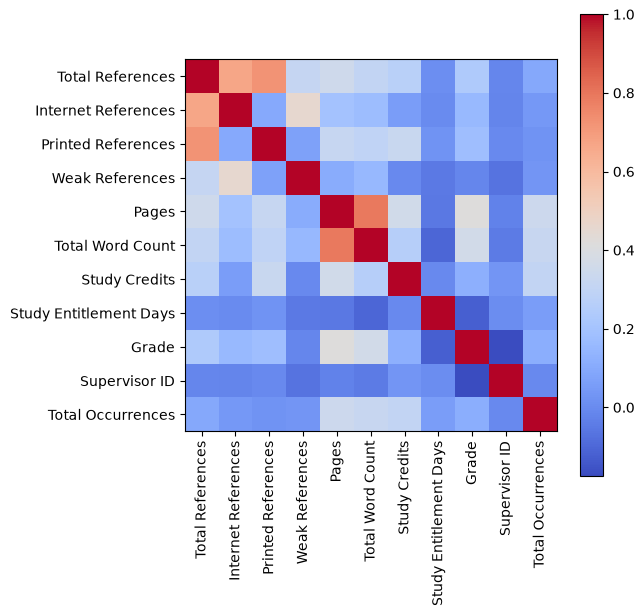

In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

In [5]:
# Keskimääräinen arvosana valvojaa kohden

grades = df.groupby("Supervisor ID")["Grade"].agg(average_grade="mean", n_theses="count")
grades = grades[grades["n_theses"] >= 10]
grades

,average_grade,n_theses
Supervisor ID,,
1,3.681818,44
2,4.088235,34
3,3.312500,32
4,4.230769,13
5,3.303030,33
10,3.250000,12
13,3.900000,20
20,3.173077,52
22,3.636364,11


### 4. Modeling and validation

#### Arvosanan ennustaminen lineaarisella regressiolla

Ennustetaan opinnäytetyön arvosanaa työn metatietojen perusteella. "Total References" jätetään pois, koska se on useimmilla riveillä internet- ja painettujen lähteiden summa, ja lineaarinen regressio olettaa syötteiden olevan toisistaan riippumattomia.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Syötteet ja kohde

features = [
    "Internet References",
    "Printed References",
    "Weak References",
    "Pages",
    "Total Word Count",
    "Study Credits",
    "Study Entitlement Days",
]
X = df[features] # inputs
y = df["Grade"] # targets

# Jaetaan data koulutus- ja testijoukkoon

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.01, 0. ,-0.07,..., 0. ,-0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Internet References','Printed References','Weak References',..., 'Total Word Count','Study Credits','Study Entitlement Days']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.301
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Arvioidaan malli testijoukolla

preds = np.clip(model.predict(X_test), 1.0, 5.0)

baseline = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))

print("Mean absolute error: %.2f" % mean_absolute_error(y_test, preds))
print("Baseline MAE (always predict mean): %.2f" % baseline)
print("RMSE: %.2f" % np.sqrt(mean_squared_error(y_test, preds)))
print("R2: %.2f" % r2_score(y_test, preds))

Mean absolute error: 0.72
Baseline MAE (always predict mean): 0.81
RMSE: 0.94
R2: -0.04


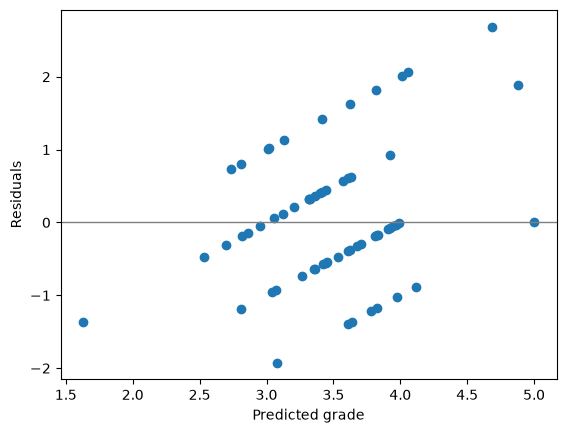

In [8]:
# Residuaalit: hajonnan tulisi olla tasaista koko ennustevälillä

plt.scatter(preds, preds - y_test)
plt.axhline(0, color='gray', linewidth=1)
plt.xlabel('Predicted grade')
plt.ylabel('Residuals')
plt.show()

#### Ristiinvalidointi

Validoidaan data käyttämällä ristiinvalidointia, jossa jaamme datan 10 osaan. Sekoitamme datan, jotta erityisesti kielet sekottuisivat. Ristiinvalidointi on luotettavampi kuin yksittäinen jako tässä tilanteessa.

In [9]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.dummy import DummyRegressor

# Ristiinvalidointi koko datalle. Verrataan tulosta siihen, että aina veikataan keskiarvoa.

cv = KFold(n_splits=10, shuffle=True, random_state=123)
scores = cross_validate(LinearRegression(), X, y, cv=cv,
                        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"])
baseline_scores = cross_validate(DummyRegressor(strategy="mean"), X, y, cv=cv, 
                        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"])

mae = -scores["test_neg_mean_absolute_error"]
rmse = -scores["test_neg_root_mean_squared_error"]
r2 = scores["test_r2"]

print("MAE: %.2f ± %.2f" % (mae.mean(), mae.std()))
print("Baseline MAE (always predict average): %.2f" % -baseline_scores["test_neg_mean_absolute_error"].mean())
print("RMSE: %.2f ± %.2f" % (rmse.mean(), rmse.std()))
print("Baseline RMSE (always predict average): %.2f" % -baseline_scores["test_neg_root_mean_squared_error"].mean())
print("R2: %.2f ± %.2f" % (r2.mean(), r2.std()))

# Ennusteen hajontana käytetään ristiinvalidoinnin RMSE:tä
deviation = rmse.mean()

MAE: 0.73 ± 0.09
Baseline MAE (always predict average): 0.85
RMSE: 0.91 ± 0.11
Baseline RMSE (always predict average): 0.99
R2: 0.10 ± 0.18


In [10]:
# Ennustefunktio: palauttaa arvosanan (1.0-5.0) ja hajonnan

def predict_grade(internet_refs, printed_refs, weak_refs, pages, word_count, study_credits, entitlement_days):
    thesis = pd.DataFrame([[internet_refs, printed_refs, weak_refs, pages, word_count, study_credits, entitlement_days]],
                          columns=features)
    grade = float(np.clip(model.predict(thesis)[0], 1.0, 5.0))
    return grade, deviation

grade, dev = predict_grade(internet_refs=20, printed_refs=5, weak_refs=1, pages=45,
                           word_count=9000, study_credits=240, entitlement_days=1460)
print("Ennustettu arvosana: %.2f ± %.2f" % (grade, dev))

Ennustettu arvosana: 3.86 ± 0.91


##### Tulosten tulkinta:
Ristiinvalidoinnissa lineaarisen regression MAE oli 0.73 arvosanapistettä joka osoittautui pienemmäksi kuin aina keskiarvoa ennustavan vertailumallin (baseline) tulos 0.85. Regressiomalli pienensi keskimääräistä absoluuttista virhettä noin 0.12 pisteellä. Malli siis ennusti MAE:n perusteella vertailumallia vain vähän paremmin.
- Mallin prosentuaalinen parannus MAE tuloksessa suhteessa vertausmallin tulokseen: (0.85-0.73)/0.85 * 100 = noin 14.1%

RMSE:n tulokseksi tuli 0.91 arvosanapistettä joka pieneni vertailumallin RMSE 0.99. RMSE rankaisee enemmän suuria virheitä kuin MAE.
- Mallin prosentuaalinen parannus RMSE tuloksessa suhteessa vertausmallin tulokseen: (0.99-0.91)/0.99 * 100 = noin 8.1%

Malli ennustaa siis vertailumallia paremmin, mutta parannus on pieni. Parannus on suurempi MAE:ssä kuin RMSE:ssä, joten malli vähentää enemmän tyypillisiä virheitä kuin suuria ennustevirheitä.

Mallin selitysaste R² oli 0.10 ± 0.18, eli malli selittää vain noin 10 % arvosanojen vaihtelusta, ja tulos vaihtelee paljon ristiinvalidoinnin osajoukkojen välillä. Lineaarinen malli pystyy siis ennustamaan arvosanoja jossain määrin, mutta ennustuskyky on heikko.

#### Association rule mining

In [11]:
df["PagesCategory"] = pd.cut(
df["Pages"],
bins=[0,40,60,80,200],
labels=["FewPages","MediumPages","ManyPages","VeryManyPages"]
)
df[["Pages", "PagesCategory"]].head()

,Pages,PagesCategory
0,27,FewPages
1,62,ManyPages
2,32,FewPages
3,46,MediumPages
4,67,ManyPages


In [12]:
df["ReferencesCategory"] = pd.cut(
df["Total References"],
bins=[0, 20, 40, 60, 200],
labels=["FewReferences", "MediumReferences",
"ManyReferences", "VeryManyReferences"]
)
df[["Total References", "ReferencesCategory"]].head()

,Total References,ReferencesCategory
0,0,NaN
1,24,MediumReferences
2,10,FewReferences
3,35,MediumReferences
4,85,VeryManyReferences


In [13]:
df["PrintedCategory"] = pd.cut(
df["Printed References"],
bins=[-1, 5, 15, 30, 200],
labels=["FewPrinted", "MediumPrinted",
"ManyPrinted", "VeryManyPrinted"]
)
df[["Printed References", "PrintedCategory"]].head()

,Printed References,PrintedCategory
0,0,FewPrinted
1,3,FewPrinted
2,1,FewPrinted
3,19,ManyPrinted
4,59,VeryManyPrinted


In [14]:
df["WeakCategory"] = pd.cut(
df["Weak References"],
bins=[-1, 0, 100],
labels=[ "NoWeak", "HasWeak" ]
)
df[["Weak References", "WeakCategory"]].head()

,Weak References,WeakCategory
0,0,NoWeak
1,2,HasWeak
2,0,NoWeak
3,0,NoWeak
4,7,HasWeak


## 5. Evaluation

## 6. Deployment